Tutorial 2

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
#Loading Dataframe:
from google.colab import drive
drive.mount('/content/drive')

csv_file_path = "/content/drive/MyDrive/AI And ML/Iris.csv"
df = pd.read_csv(csv_file_path)
print("Dataset Preview:")
print(df.head())
print("\nDataset Shape:")
print(df.info())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Preview:
   5.1  3.5  1.4  0.2  Iris-setosa
0  4.9  3.0  1.4  0.2  Iris-setosa
1  4.7  3.2  1.3  0.2  Iris-setosa
2  4.6  3.1  1.5  0.2  Iris-setosa
3  5.0  3.6  1.4  0.2  Iris-setosa
4  5.4  3.9  1.7  0.4  Iris-setosa

Dataset Shape:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB
None


In [6]:
#Extract features(X) and target labels(y)
#all column expect first and last one since first column is an index
X = df.iloc[:, :-1].values
#last column(target)
y = df.iloc[:, -1].values
#Convert categorial labels to numeric
label_encoder = LabelEncoder()
#Convert label to integer(0,1,2)
y_encoded = label_encoder.fit_transform(y)
#One hot encde
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))
#Display results
print("\nEncoded Labels:" , np.unique(y_encoded))
print("Unique Classes:", np.unique(y_encoded))
print("\nOne-Hot Encoded Labels:\n", y_one_hot[:5])





Encoded Labels: [0 1 2]
Unique Classes: [0 1 2]

One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [7]:
#Splite dataset into training(808) and testing
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot)
#OUtput shapes
print("\nTraining Data Shape:")
print("X_train:",X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)



Training Data Shape:
X_train: (119, 4) y_train: (119, 3)
X_test: (30, 4) y_test: (30, 3)


In [8]:
import numpy as np
def softmax(z):
  z_shifted = z-np.max(z, axis=1, keepdims=True)
  exp_z = np.exp(z_shifted)
  return exp_z/np.sum(exp_z, axis=1, keepdims=True)

In [9]:
def loss_softmax(y_pred, y):
  #to avoid log(0)
  epsilon = 1e-12
  #Prevent log(0) by clipping values
  y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
  n = y.shape[0]
  loss = -np.sum(y*np.log(y_pred)) / n
  return loss

In [10]:
def cost_softmax(X,y,W,b):
  n = X.shape[0]
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  cost = loss_softmax(y_pred, y)
  return cost

In [11]:
def compute_gradient_softmax(X,y,W,b):
  n, d = X.shape
  z = np.dot(X,W) +b
  y_pred = softmax(z)
  #Gradient with respect to weights
  grad_W = np.dot(X.T, (y_pred - y)) / n
  #Gradient with respect to biases
  grad_b = np.sum(y_pred - y, axis=0)
  return grad_W, grad_b

In [12]:
def gradient_descent_softmax(X,y,W,b, alpha, n_iter, show_cost=False):
  cost_history=[]
  for i in range(n_iter):
    #Compute gradients
    grad_W, grad_b = compute_gradient_softmax(X,y,W,b)
    #Update weigghts and bibases using gradiets
    W = W - alpha * grad_W
    b = b - alpha * grad_b

    #COmpute and store cost
    cost = cost_softmax(X,y,W,b)
    cost_history.append(cost)

    #Print cost at regular intervals
    if show_cost and (i % 100 == 0 or i == n_iter -1):
      print(f"Iteration {i} : Cost = {cost:.6f}")
  return W, b, cost_history


In [13]:
def predict_softmax(X,W,b):
  #Compute the score
  z = np.dot(X,W) + b
  #Apply softmax to get probabilities
  y_pred = softmax(z)
  #Assign the class with the highest probability
  predicted_classes = np.argmax(y_pred, axis=1)
  return predicted_classes

Iteration 0 : Cost = 1.055976
Iteration 100 : Cost = 2.877666
Iteration 200 : Cost = 1.076742
Iteration 300 : Cost = 0.132425
Iteration 400 : Cost = 0.109489
Iteration 500 : Cost = 0.102194
Iteration 600 : Cost = 0.096549
Iteration 700 : Cost = 0.092067
Iteration 800 : Cost = 0.088427
Iteration 900 : Cost = 0.085411
Iteration 999 : Cost = 0.082889


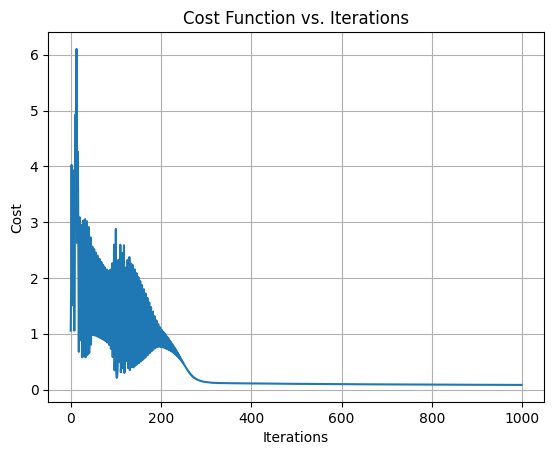

In [14]:
import matplotlib.pyplot as plt
#Initialize te weights and biases
#NUmber of features
d = X_train.shape[1]
#NUmber of classes
c = y_train.shape[1]
#Small random weights
W= np.random.randn(d,c) * 0.01
#bias initialized o
b= np.zeros(c)
#Set hyperparameters
alpha = 0.1
n_iter = 1000
#Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter,show_cost=True)
#plot the cost histor to visualize convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
#evaluation Function
def evaluate_classification(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)#COmpute precision, recaal and F1 score
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  return cm, precision, recall, f1


In [16]:
#Predict on test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
#Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1)
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
#Print evaluation etrcies
print("\n Confusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


 Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
